# Edge Features Explorer

This notebook explores edge features from phylogenetic graph data.
For each edge in a specified graph, we analyze the distribution of feature values.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## Configuration

Set the path to your edge CSV file and the graph_id to analyze.

In [45]:
# Configuration
edge_file_path = "/Users/lukelyu/Desktop/epidata/100_10_new/0_edge.csv"
target_graph_id = "0_0"  # Change this to explore different graphs

## Load and Parse Data

In [46]:
# Load the CSV file
df = pd.read_csv(edge_file_path)

print(f"Total edges in file: {len(df)}")
print(f"Unique graph IDs: {df['graph_id'].nunique()}")

Total edges in file: 495
Unique graph IDs: 10


In [47]:
# Filter by target graph_id
df_filtered = df[df['graph_id'] == target_graph_id].copy()

print(f"Number of edges in graph '{target_graph_id}': {len(df_filtered)}")

if len(df_filtered) == 0:
    print(f"\nWarning: No edges found for graph_id '{target_graph_id}'")
    print(f"Available graph_ids: {sorted(df['graph_id'].unique())}")

Number of edges in graph '0_0': 45


In [48]:
def parse_edge_features(feature_string):
    """
    Parse edge features from string format.
    The features are stored as [value1\tvalue2\tvalue3...]
    """
    # Remove brackets and split by tab or whitespace
    feature_string = str(feature_string).strip()
    if feature_string.startswith('['):
        feature_string = feature_string[1:]
    if feature_string.endswith(']'):
        feature_string = feature_string[:-1]
    
    # Split by tab or whitespace and convert to float
    values = [float(x.strip()) for x in feature_string.split() if x.strip()]
    return np.array(values)

# Parse edge features for filtered data
df_filtered['features_array'] = df_filtered['edge_features'].apply(parse_edge_features)

# Check parsing
if len(df_filtered) > 0:
    print(f"Example edge features (first edge):")
    print(f"  Length: {len(df_filtered.iloc[0]['features_array'])}")
    print(f"  First 10 values: {df_filtered.iloc[0]['features_array'][:10]}")

Example edge features (first edge):
  Length: 28
  First 10 values: [ 74.53682797  74.65615062  74.69494339 105.97237857 112.32422419
 125.00985255 128.18557156 128.30489421 129.96658817 130.61654082]


## Calculate Statistics for Each Edge

In [49]:
def calculate_statistics(features_array):
    """
    Calculate min, 25%, median, 75%, max for a feature array.
    """
    return {
        'min': np.min(features_array),
        'q25': np.percentile(features_array, 25),
        'median': np.median(features_array),
        'q75': np.percentile(features_array, 75),
        'max': np.max(features_array)
    }

# Calculate statistics for each edge
stats_list = []
for idx, row in df_filtered.iterrows():
    stats = calculate_statistics(row['features_array'])
    stats['edge_label'] = f"{row['node1']}-{row['node2']}"
    stats['node1'] = row['node1']
    stats['node2'] = row['node2']
    stats['feature_count'] = len(row['features_array'])
    stats_list.append(stats)

stats_df = pd.DataFrame(stats_list)

print(f"\nStatistics for {len(stats_df)} edges:")
stats_df


Statistics for 45 edges:


,min,q25,median,q75,max,edge_label,node1,node2,feature_count
0,74.536828,128.275064,176.960841,192.851766,219.227765,1-1,1,1,28
1,19.316772,109.932385,175.046164,205.715246,226.324871,2-2,2,2,105
2,51.384068,93.454430,135.524792,141.757741,147.990690,3-3,3,3,3
3,106.648881,157.947912,182.071076,198.481721,228.637387,4-4,4,4,66
4,135.288607,197.508676,201.082902,206.208486,213.626337,5-5,5,5,28
5,176.121437,203.879813,209.348149,211.084567,219.080762,6-6,6,6,6
6,89.204153,151.636591,190.897367,203.042357,209.395687,7-7,7,7,6
7,229.256957,229.256957,229.256957,229.256957,229.256957,8-8,8,8,1
8,191.502020,191.502020,191.502020,191.502020,191.502020,9-9,9,9,1
9,115.865387,173.852138,184.248357,199.917389,232.239020,1-2,1,2,120


## Visualizations

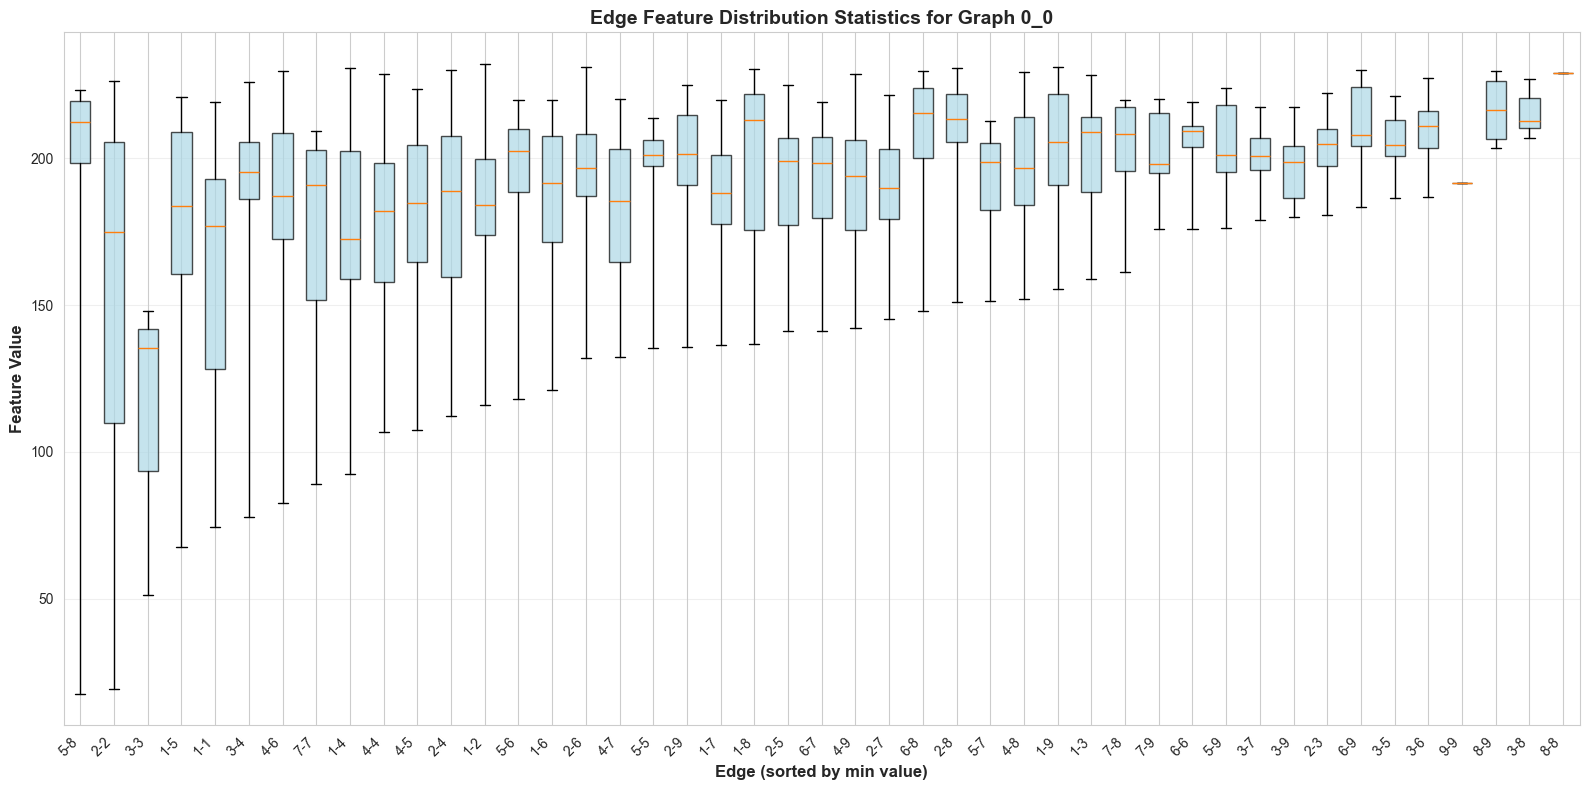

In [50]:
# Sort stats_df by minimum value
stats_df_sorted = stats_df.sort_values('min').reset_index(drop=True)

# Box plot representation for each edge (sorted by min)
fig, ax = plt.subplots(figsize=(16, 8))

# Create box plot data manually using sorted dataframe
positions = range(len(stats_df_sorted))
box_data = []

for idx, row in stats_df_sorted.iterrows():
    # Create a box plot with our statistics
    box_data.append([row['min'], row['q25'], row['median'], row['q75'], row['max']])

# Use bxp for custom box plot
bp_dicts = []
for i, (pos, data) in enumerate(zip(positions, box_data)):
    bp_dict = {
        'label': stats_df_sorted.iloc[i]['edge_label'],
        'whislo': data[0],  # min
        'q1': data[1],      # 25%
        'med': data[2],     # median
        'q3': data[3],      # 75%
        'whishi': data[4],  # max
        'fliers': []        # no outliers in this representation
    }
    bp_dicts.append(bp_dict)

bp = ax.bxp(bp_dicts, positions=positions, widths=0.6, 
            patch_artist=True, showfliers=False)

# Customize colors
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_xlabel('Edge (sorted by min value)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Value', fontsize=12, fontweight='bold')
ax.set_title(f'Edge Feature Distribution Statistics for Graph {target_graph_id}', 
             fontsize=14, fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(stats_df_sorted['edge_label'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()